# Merging data

In [ ]:
from data_batching import DataBatcher
from alpaca_keys import ALPACA_API_KEY, ALPACA_SECRET_KEY

from alpaca.trading.client import TradingClient
from alpaca.trading.requests import GetAssetsRequest
from alpaca.trading.enums import AssetStatus, AssetClass

from datetime import datetime



In [ ]:
client = TradingClient(ALPACA_API_KEY, ALPACA_SECRET_KEY, paper=True)

# Get all tickers
search_params = GetAssetsRequest(asset_class=AssetClass.US_EQUITY, status=AssetStatus.ACTIVE)
assets = client.get_all_assets(search_params)
all_tickers = [asset.symbol for asset in assets if asset.tradable]

# Get batched data
db = DataBatcher(all_tickers, batch_size=50, output_dir='data')
db.batch_tickers(time_frame='day', start_date=datetime(2023,1,1))
db.merge_batched_data()

# Data pre-processing

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_parquet('data/merged_data.parquet')
print(data.shape)

(7780291, 9)


Let's check how much market days for each company we have

In [2]:
market_days = data.groupby('symbol')['symbol'].count().to_frame()
market_days.columns = ['count']
market_days.index.name = None
market_days['pct'] = round(market_days['count'] / market_days['count'].max(),3)
market_days.sort_values(by='count', ascending=True, inplace=True)

print(f'Min number of days: {min(market_days['count'])}')
print(f'Max number of days: {max(market_days['count'])}')

market_days

Min number of days: 1
Max number of days: 796


,count,pct
RVI,1,0.001
TDOT,1,0.001
MMED,1,0.001
BUI.RTWI,1,0.001
VMET,1,0.001
...,...,...
AAOI,796,1.000
AAMI,796,1.000
AA,796,1.000
ZYME,796,1.000


In [3]:
bins = np.round(np.arange(0, 1.1, 0.1),2)
labels = ['0-10','10-20','20-30','30-40','40-50','50-60','60-70','70-80','80-90','90-100']

market_days['bin'] = pd.cut(market_days['pct'], bins=bins, labels=labels, include_lowest=True)
plot_data = market_days.groupby('bin')['bin'].count()
plot_data

bin
0-10       724
10-20      649
20-30      582
30-40      477
40-50      355
50-60      324
60-70      268
70-80      285
80-90      203
90-100    8441
Name: bin, dtype: int64

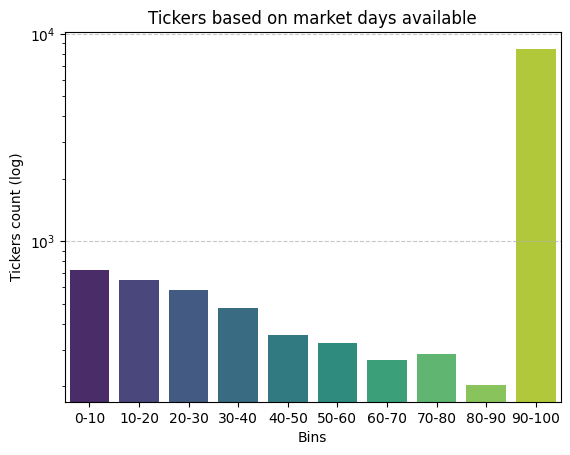

In [4]:
sns.barplot(
    x=plot_data.index, 
    y=plot_data.values, 
    hue=plot_data.index, 
    palette='viridis', 
    legend=False,
    dodge=False
)

plt.yscale('log') 
plt.title('Tickers based on market days available')
plt.xlabel('Bins')
plt.ylabel('Tickers count (log)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Leaving only the companies that were present on the market from 2023-01-01 to 2026-03-06, with high number of market days.

In [5]:
full_tickers = list(market_days[market_days['bin'] == '90-100'].index)
data = data[data['symbol'].isin(full_tickers)].reset_index(drop=True)
data

,symbol,timestamp,open,high,low,close,volume,trade_count,vwap
0,XUSP,2023-01-03 05:00:00+00:00,24.2700,24.2700,24.1000,24.2112,1918.0,16.0,24.167778
1,XUSP,2023-01-04 05:00:00+00:00,24.3400,24.3400,24.3010,24.3010,315.0,5.0,24.340000
2,XUSP,2023-01-05 05:00:00+00:00,24.1700,24.1900,24.0620,24.0620,1022.0,10.0,24.127063
3,XUSP,2023-01-06 05:00:00+00:00,24.4100,24.7200,24.4100,24.6504,1563.0,19.0,24.635653
4,XUSP,2023-01-09 05:00:00+00:00,24.9791,24.9791,24.6377,24.6377,677.0,8.0,24.843919
...,...,...,...,...,...,...,...,...,...
6711810,XTN,2026-03-02 05:00:00+00:00,100.1900,102.4600,100.0101,102.2750,31597.0,550.0,101.956931
6711811,XTN,2026-03-03 05:00:00+00:00,99.6000,102.2400,98.4800,101.5500,49343.0,645.0,101.280939
6711812,XTN,2026-03-04 05:00:00+00:00,102.3400,102.3400,101.2600,101.2600,50258.0,467.0,101.493082
6711813,XTN,2026-03-05 05:00:00+00:00,100.1400,100.1400,96.7800,97.1400,93475.0,721.0,97.384718


# Analysis

In [6]:
import pandas as pd
from ga_module import GeneticPortfolio
import numpy as np

In [7]:
gp = GeneticPortfolio(data)
gp.get_data()

,symbol,timestamp,open,high,low,close,volume,trade_count,vwap,returns
0,XUSP,2023-01-03 05:00:00+00:00,24.2700,24.2700,24.1000,24.2112,1918.0,16.0,24.167778,0.000000
1,XUSP,2023-01-04 05:00:00+00:00,24.3400,24.3400,24.3010,24.3010,315.0,5.0,24.340000,0.003709
2,XUSP,2023-01-05 05:00:00+00:00,24.1700,24.1900,24.0620,24.0620,1022.0,10.0,24.127063,-0.009835
3,XUSP,2023-01-06 05:00:00+00:00,24.4100,24.7200,24.4100,24.6504,1563.0,19.0,24.635653,0.024453
4,XUSP,2023-01-09 05:00:00+00:00,24.9791,24.9791,24.6377,24.6377,677.0,8.0,24.843919,-0.000515
...,...,...,...,...,...,...,...,...,...,...
6711810,XTN,2026-03-02 05:00:00+00:00,100.1900,102.4600,100.0101,102.2750,31597.0,550.0,101.956931,-0.000733
6711811,XTN,2026-03-03 05:00:00+00:00,99.6000,102.2400,98.4800,101.5500,49343.0,645.0,101.280939,-0.007089
6711812,XTN,2026-03-04 05:00:00+00:00,102.3400,102.3400,101.2600,101.2600,50258.0,467.0,101.493082,-0.002856
6711813,XTN,2026-03-05 05:00:00+00:00,100.1400,100.1400,96.7800,97.1400,93475.0,721.0,97.384718,-0.040687


In [ ]:
pop = gp.get_population()
fitnes = gp.evaluate_portfolios(pop)